# Leapfrog Integration of a Harmonic Oscillator

**Thomas Griffiths** — University of Washington Astronomy Department

This is the first test model in a study of leapfrog numerical integration,
preceding `Bouncing_ball.ipynb` and the later correction-methods work. The
simple harmonic oscillator (SHO) is used as a validation case because it has
an exact analytic solution, which makes it straightforward to measure
integration error directly and verify that the leapfrog method has the
expected second-order convergence ($O(h^2)$) before applying it to the
harder discontinuous-force cases.

## What's in this notebook
1. **1D SHO — two leapfrog implementations** — a "modified" leapfrog
   (standard symplectic form, velocity half-kicked before and after each
   position update) versus an "original" version (single full velocity kick
   per step), with energy compared between the two.
2. **2D SHO** — the leapfrog extended to two dimensions with independent
   frequencies $\omega_x \neq \omega_y$, producing Lissajous-style
   trajectories. Includes x/y position-velocity plots, a 3D phase-space
   visualization, and an x-vs-y Lissajous figure.
3. **Solutions comparison** — leapfrog position and velocity compared against
   the exact analytic solution ($x = A\cos(\omega t)$,
   $v = -A\omega\sin(\omega t)$) over 10 orbits.
4. **Convergence analysis** — final, maximum, and RMS error vs. stepsize
   across a log-spaced range ($10^{-4}$ to $10^0$), all checked against the
   expected $h^2$ reference line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as const

Two implementations of the leapfrog integrator are compared here for the
1D SHO. The "modified" version is the standard **symplectic** form — velocity
is half-kicked before and after each position update ($v_{i+1/2}$ staggered
relative to $x$) — which conserves a shadow Hamiltonian exactly and keeps
energy bounded over long integrations. The "original" version applies a
single full velocity kick per step without staggering, which breaks the
symplectic property and leads to energy drift visible in the comparison plot
below.

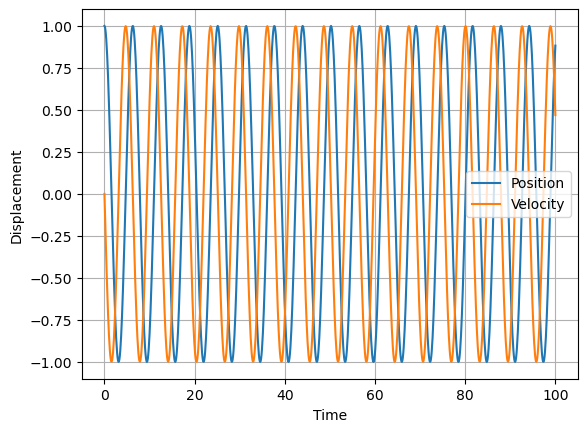

In [2]:
#Timestep
N = 1000 
t = np.linspace(0,100,N) 
dt = t[1]-t[0]

#Paramters
k = 1
m = 1
x0 = 1
v0 = 0
w = 1 #w = np.sqrt(k/m) = 1

#Modified Leapfrog Integrator
def integrator(x0, v0, w, N, dt): 
     x = np.zeros(N)
     v = np.zeros(N)

     #Initial positions
     x[0] = x0 
     v[0] = v0
     
     #Equations of Motion
     for i in range(N-1):
        v[i+1] = v[i] + x[i] * (-w**2) * 0.5 * dt
        x[i+1] = x[i] + v[i+1] * dt
        v[i+1] = v[i+1] + x[i+1] * (-w**2) * 0.5 * dt

     return x,v
     
x,v = integrator(x0, v0, w, N, dt)
     
plt.figure()
plt.plot(t, x, label = 'Position')
plt.plot(t, v, label = 'Velocity')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()
plt.show()


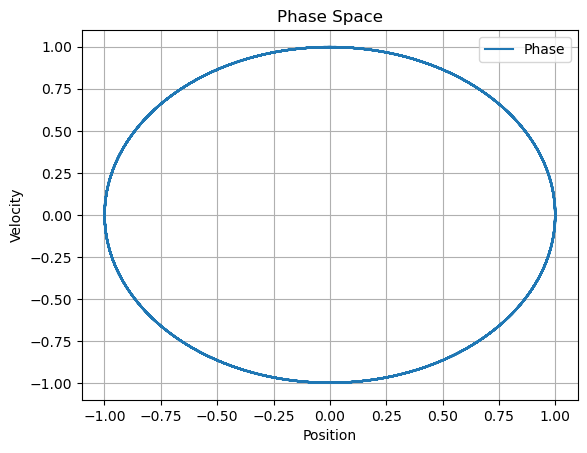

In [3]:
plt.figure()
plt.plot(x,v, label = "Phase")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title('Phase Space')
plt.legend()
plt.grid()
plt.show()

In [4]:
#Energy using modified version
KE = 0.5 * m * v**2
PE = 0.5 * k * x**2
E = PE + KE

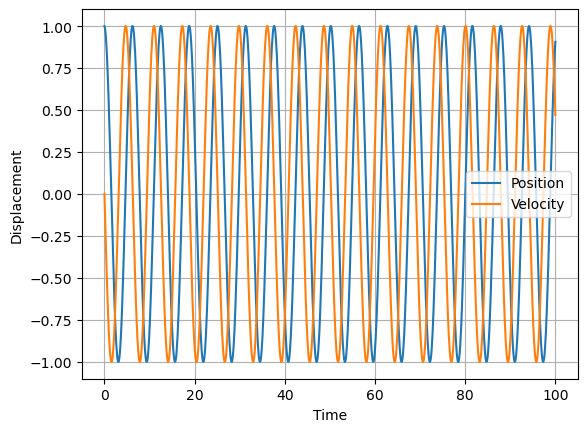

In [5]:
#Original Leapfrog Integrator
def integrator_original(x0, v0, w, N, dt): 
     x = np.zeros(N)
     v = np.zeros(N)

     #Initial positions
     x[0] = x0 
     v[0] = v0
     
     #Equaitons of Motion
     for i in range(N-1):
        v[i+1] = v[i] + x[i] * (-w**2) * dt
        x[i+1] = x[i] + v[i+1] * dt
        
     return x,v

x,v = integrator_original(x0, v0, w, N, dt)

plt.figure()
plt.plot(t, x, label = 'Position')
plt.plot(t, v, label = 'Velocity')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()
plt.show()

In [6]:
E_original = 0.5 * m * v**2 + 0.5 * k * x**2

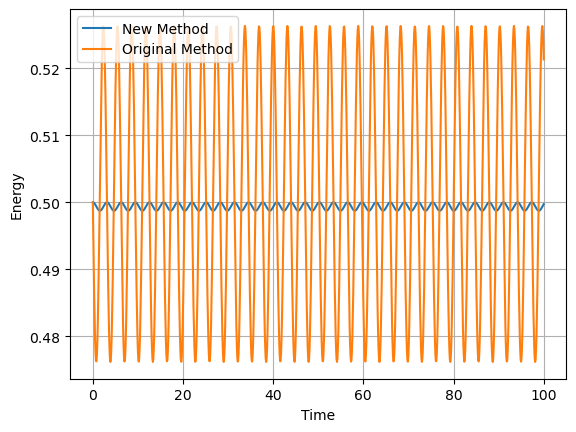

In [7]:
#Plot comparison of the two forms of Leapfrog Integration

plt.figure()
plt.plot(t, E, label = 'New Method')
plt.plot(t, E_original, label = 'Original Method')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.legend()
plt.grid()
plt.show()

# 2D Simple Harmonic Oscillator

Extending to two independent harmonic oscillators with frequencies
$\omega_x$ and $\omega_y$. When the ratio $\omega_x / \omega_y$ is
rational the trajectory is a closed Lissajous figure; an irrational ratio
gives a curve that eventually densely fills a rectangle in the $x$-$y$
plane. The 3D phase-space plot (`my_cube_plot`) shows both $(x, v_x)$ and
$(y, v_y)$ trajectories as curves in (position, velocity, time) space.

In [8]:
from mpl_toolkits.mplot3d import Axes3D

In [9]:
#Parameters

k_x = 1
k_y = 1
m = 1
x0 = 1
y0 = 1
v_x0 = 0
v_y0 = 0
w_x = 2 
w_y = 1

In [10]:
#2D Leapfrog Integrator
def integrator_2d(x0, y0, v_x0, v_y0, w_x, w_y, N, dt): 
     x = np.zeros(N)
     y = np.zeros(N)
     v_x = np.zeros(N)
     v_y = np.zeros(N)

     #Initial positions
     x[0] = x0 
     y[0] = y0
     v_x[0] = v_x0
     v_y[0] = v_y0

     #Equations of Motion
     for i in range(N-1):
         v_x[i+1] = v_x[i] + x[i] * (-w_x**2) * 0.5 * dt
         v_y[i+1] = v_y[i] + y[i] * (-w_y**2) * 0.5 * dt
         x[i+1] = x[i] + v_x[i+1] * dt
         y[i+1] = y[i] + v_y[i+1] * dt
         v_x[i+1] = v_x[i+1] + x[i+1] * (-w_x**2) * 0.5 * dt
         v_y[i+1] = v_y[i+1] + y[i+1] * (-w_y**2) * 0.5 * dt

     return x,y,v_x, v_y
     
x,y,v_x,v_y = integrator_2d(x0, y0, v_x0, v_y0, w_x, w_y, N, dt)


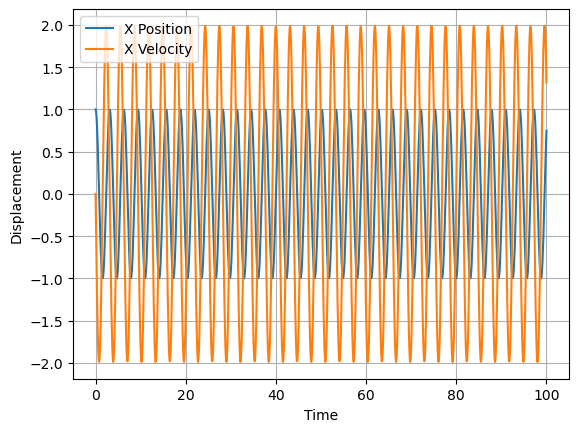

In [11]:
plt.figure()
plt.plot(t, x, label = 'X Position')
plt.plot(t, v_x, label = 'X Velocity')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()
plt.show()

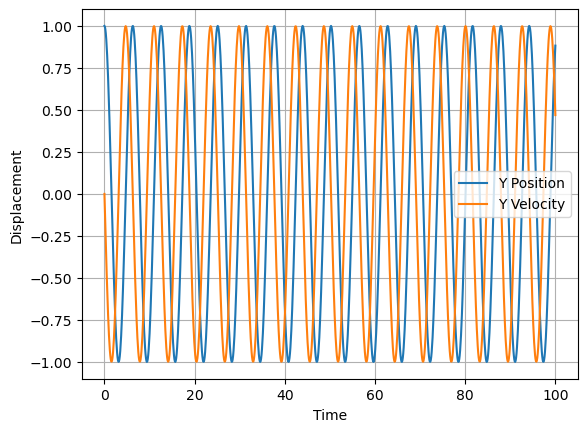

In [12]:
plt.figure()
plt.plot(t, y, label = 'Y Position')
plt.plot(t, v_y, label = 'Y Velocity')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()
plt.show()

In [13]:
def my_cube_plot(x, y, v_x, v_y, t, w_x, w_y, my_azimuth, my_elevation):
    fig, ax = plt.subplots(
        subplot_kw={'projection': '3d'},
        figsize = (9, 9), 
        constrained_layout = True
        )
    
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel('Time')  

    ax.plot(x, v_x, t,
            color = 'Firebrick',
            marker = 'None',
            label = 'X Position and Velocity',
            linestyle = '--',
            linewidth = 3)
    
    ax.plot(y, v_y, t,
              color = 'b',
              label = 'Y Position and Velocity',
              linestyle = '--',
              linewidth = 3)

    ax.legend()
    ax.view_init(azim = my_azimuth, elev = my_elevation)
    
    plt.show()

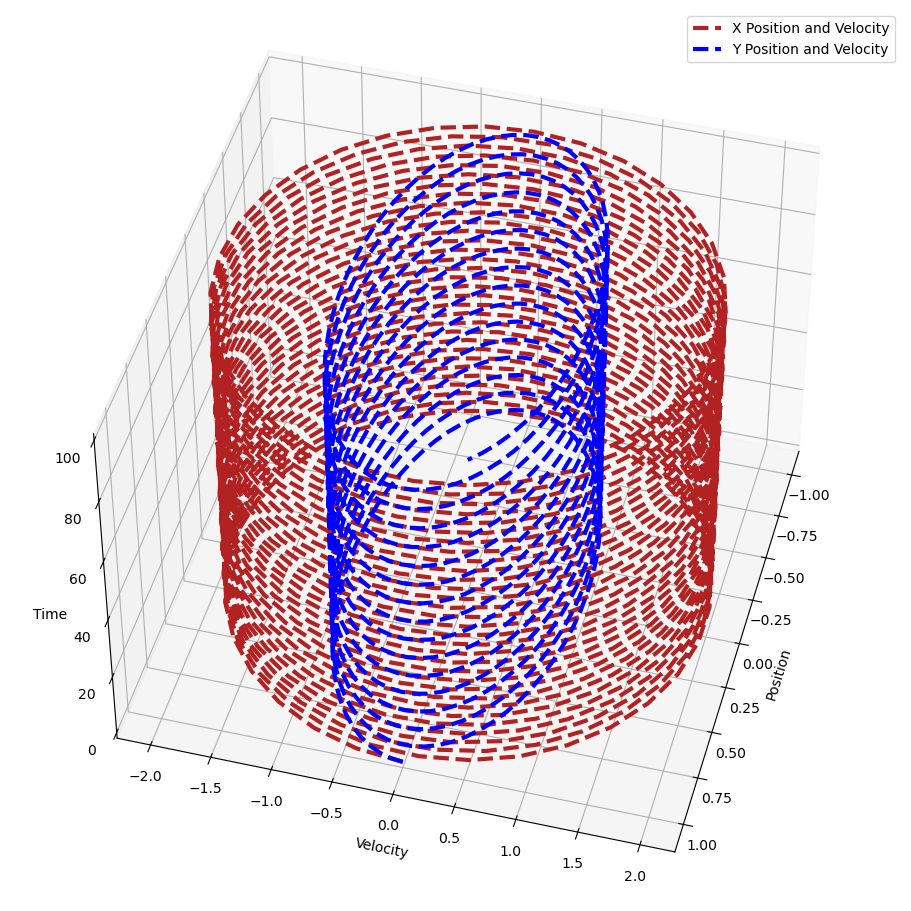

In [14]:
my_cube_plot(x, y, v_x, v_y, t, w_x, w_y, my_azimuth = 15, my_elevation = 45
)

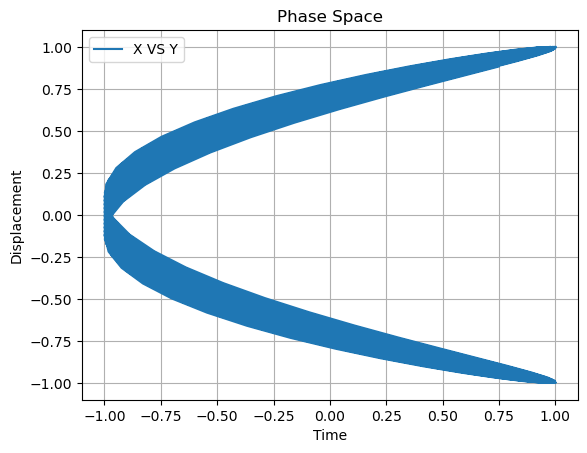

In [15]:
plt.figure()
plt.plot(x, y, label = 'X VS Y')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Phase Space')
plt.legend()
plt.grid()
plt.show()

# Solution Comparions

Comparing the leapfrog numerical solution against the exact analytic
solution $x(t) = A\cos(\omega t)$, $v(t) = -A\omega\sin(\omega t)$ over
10 orbits. The difference plot shows the phase error accumulating slowly
over time, characteristic of a symplectic integrator, which conserves
energy but not phase exactly.

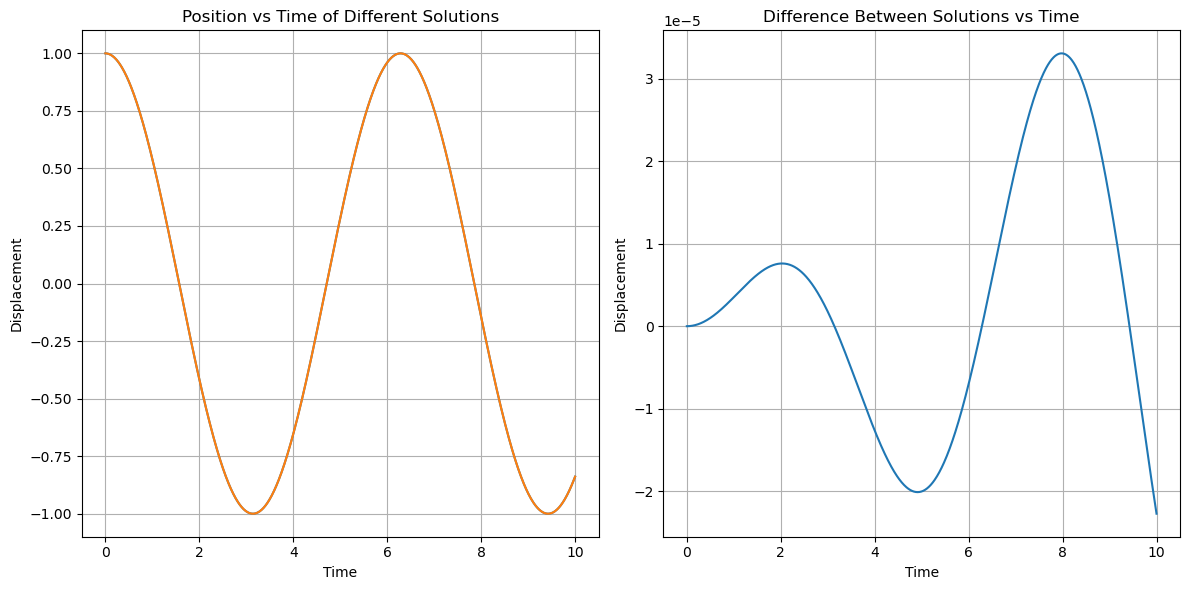

In [16]:
N = 1000
t = np.linspace(0,10,N) 
dt = t[1]-t[0]

orbits = 10
x0 = 1
v0 = 0
w = 1
A = x0
T = 2 * np.pi/w
t_final = orbits * T

   # Analytic
def analytic_solution(A, w, t):
    x_analytic = A * np.cos(w * t)
    v_analytic = -A * w * np.sin(w * t)

    return x_analytic, v_analytic

   #Numerical
def numerical_solution(x0, v0, w, N, dt): 
    x = np.zeros(N)
    v = np.zeros(N)

    # Initial positions
    x[0] = x0 
    v[0] = v0

    # Equations of motion
    for i in range(N-1):
        v[i+1] = v[i] + x[i] * (-w**2) * 0.5 * dt
        x[i+1] = x[i] + v[i+1] * dt
        v[i+1] = v[i+1] + x[i+1] * (-w**2) * 0.5 * dt

    return x, v

x_analytic, v_analytic = analytic_solution(A, w, t)
x_numerical, v_numerical = numerical_solution(x0, v0, w, N, dt)

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(t, x_analytic, label = 'Analytic Position')
plt.plot(t, x_numerical, label = 'Numerical Position')
plt.xlabel("Time")
plt.ylabel('Displacement')
plt.title('Position vs Time of Different Solutions')
plt.grid()

plt.subplot(1,2,2)
plt.plot(t, x_analytic - x_numerical)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Difference Between Solutions vs Time')
plt.grid()

plt.tight_layout()
plt.show()

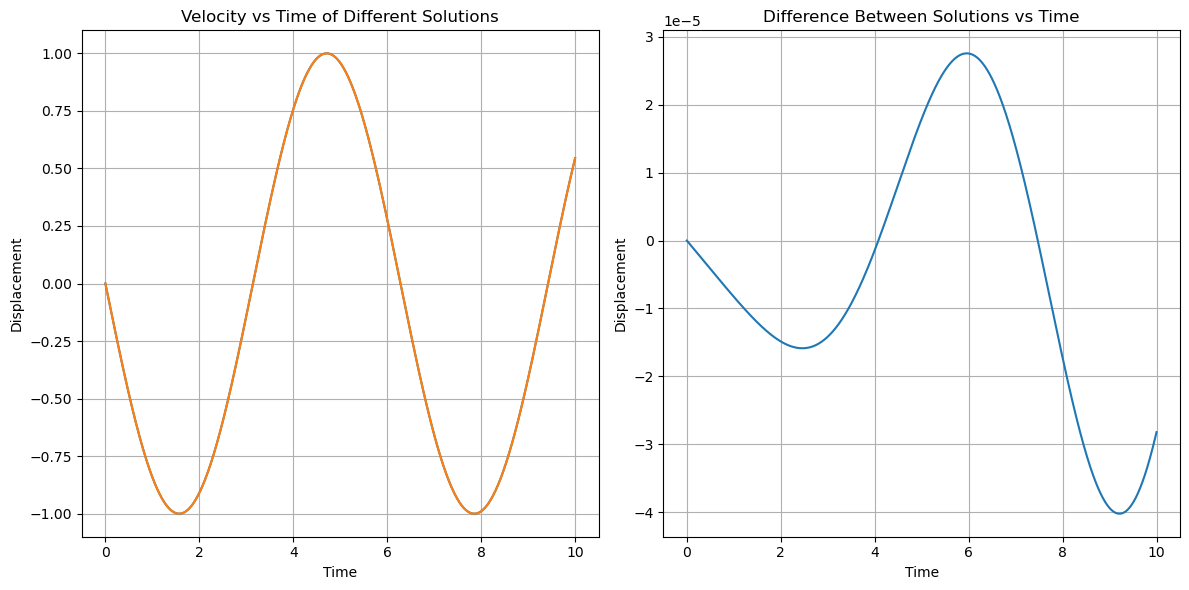

In [17]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(t, v_analytic, label = 'Analytic Velocity')
plt.plot(t, v_numerical, label = 'Numerical Velocity')
plt.xlabel("Time")
plt.ylabel('Displacement')
plt.title('Velocity vs Time of Different Solutions')
plt.grid()

plt.subplot(1,2,2)
plt.plot(t, v_analytic - v_numerical)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Difference Between Solutions vs Time')
plt.grid()

plt.tight_layout()
plt.show()

Three error metrics are each computed over a log-spaced range of stepsizes
($10^{-4}$ to $10^0$), measuring how closely the leapfrog solution matches
the analytic solution:

- **Final error** (cell below) — absolute difference at the last timestep
  after 1 orbit; sensitive to phase alignment.
- **Maximum error** — worst-case pointwise deviation over 10 orbits; a more
  conservative upper bound.
- **RMS error** — root-mean-square deviation over 10 orbits; a representative
  average performance measure.

All three are overlaid in the final combined plot to confirm they all follow
the expected $h^2$ scaling — the hallmark of a second-order integrator.

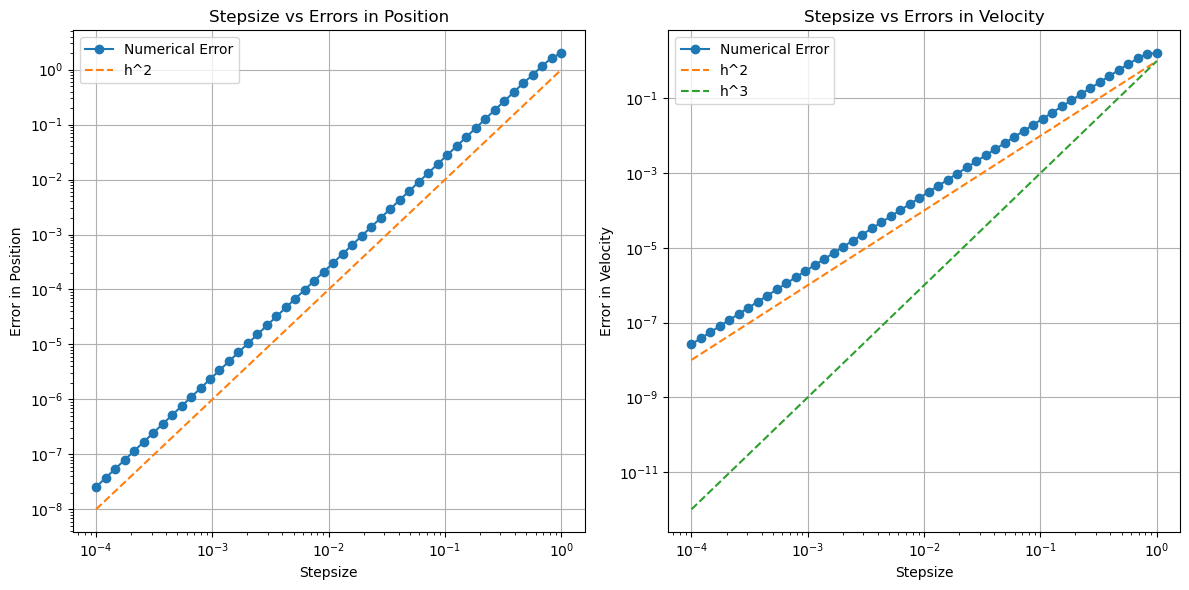

In [19]:
#Parameters
orbits = 10
x0 = 1
v0 = 0
w = 1
A = x0
T = 2 * np.pi/w
t_final = orbits * T

   # Analytic
def analytic_solution(A, w, t):
    x_analytic = A * np.cos(w * t)
    v_analytic = -A * w * np.sin(w * t)

    return x_analytic, v_analytic

   #Numerical
def numerical_solution(x0, v0, w, N, dt): 
    x = np.zeros(N)
    v = np.zeros(N)

    # Initial positions
    x[0] = x0 
    v[0] = v0

    # Equations of motion
    for i in range(N-1):
        v[i+1] = v[i] + x[i] * (-w**2) * 0.5 * dt
        x[i+1] = x[i] + v[i+1] * dt
        v[i+1] = v[i+1] + x[i+1] * (-w**2) * 0.5 * dt

    return x, v

#Step Size
stepsizes = np.logspace(-4,0,50)

max_errors_position = []
max_errors_velocity = []

for h in stepsizes:
    N = int(t_final / h) + 1
    t = np.linspace(0, t_final, N)
    dt = t[1] - t[0]

    x_analytic, v_analytic = analytic_solution(A, w, t)
    x_numerical, v_numerical = numerical_solution(x0, v0, w, N, dt)

    # Error Calculation
    error_x = np.max(np.abs(x_numerical - x_analytic))
    error_v = np.max(np.abs(v_numerical - v_analytic))

    max_errors_position.append(error_x)
    max_errors_velocity.append(error_v)
    
#Position Plots
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(stepsizes, max_errors_position, label = 'Numerical Error', marker = 'o')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Position')
plt.title('Stepsize vs Errors in Position')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(stepsizes, max_errors_velocity, label = 'Numerical Error', marker = 'o')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.plot(stepsizes, np.array(stepsizes)**3, linestyle = 'dashed', label = 'h^3')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Velocity')
plt.title('Stepsize vs Errors in Velocity')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

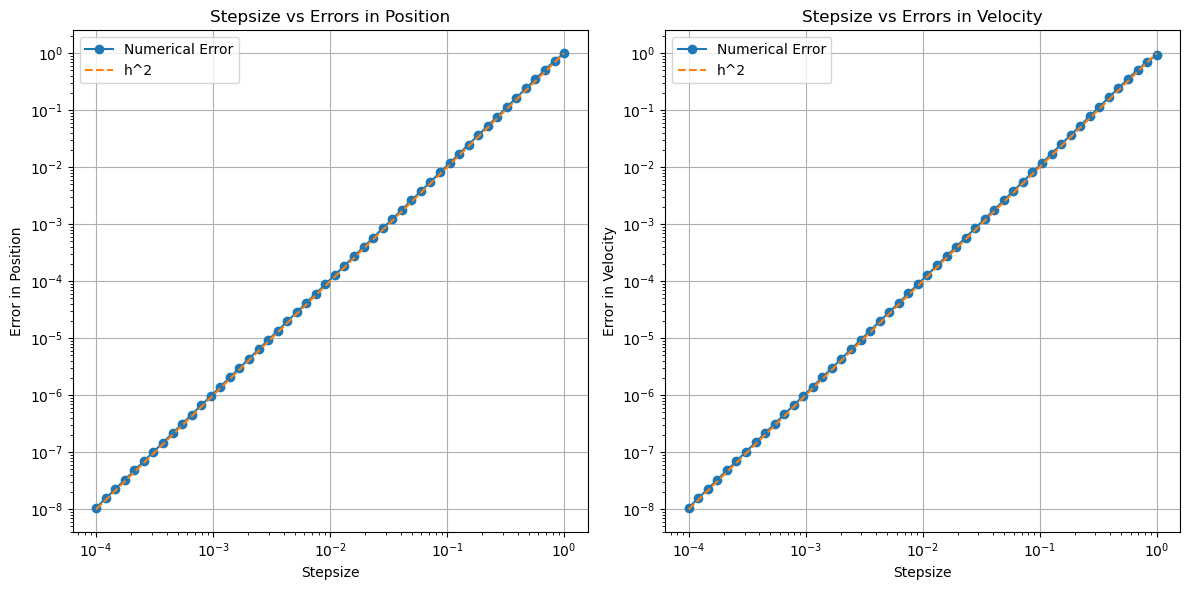

In [20]:
#Parameters
orbits = 10
x0 = 1
v0 = 0
w = 1
A = x0
T = 2 * np.pi/w
t_final = orbits * T

   # Analytic
def analytic_solution(A, w, t):
    x_analytic = A * np.cos(w * t)
    v_analytic = -A * w * np.sin(w * t)

    return x_analytic, v_analytic

   #Numerical
def numerical_solution(x0, v0, w, N, dt): 
    x = np.zeros(N)
    v = np.zeros(N)

    # Initial positions
    x[0] = x0 
    v[0] = v0

    # Equations of motion
    for i in range(N-1):
        v[i+1] = v[i] + x[i] * (-w**2) * 0.5 * dt
        x[i+1] = x[i] + v[i+1] * dt
        v[i+1] = v[i+1] + x[i+1] * (-w**2) * 0.5 * dt

    return x, v

#Step Size
stepsizes = np.logspace(-4,0,50)

rms_errors_position = []
rms_errors_velocity = []

for h in stepsizes:
    N = int(t_final / h) + 1
    t = np.linspace(0, t_final, N)
    dt = t[1] - t[0]

    x_analytic, v_analytic = analytic_solution(A, w, t)
    x_numerical, v_numerical = numerical_solution(x0, v0, w, N, dt)

    # Error Calculation
    error_x = np.sqrt(np.mean((x_numerical - x_analytic)**2))
    error_v = np.sqrt(np.mean((v_numerical - v_analytic)**2))

    rms_errors_position.append(error_x)
    rms_errors_velocity.append(error_v)
    
#Position Plots
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(stepsizes, rms_errors_position, label = 'Numerical Error', marker = 'o')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Position')
plt.title('Stepsize vs Errors in Position')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(stepsizes, rms_errors_velocity, label = 'Numerical Error', marker = 'o')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Velocity')
plt.title('Stepsize vs Errors in Velocity')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

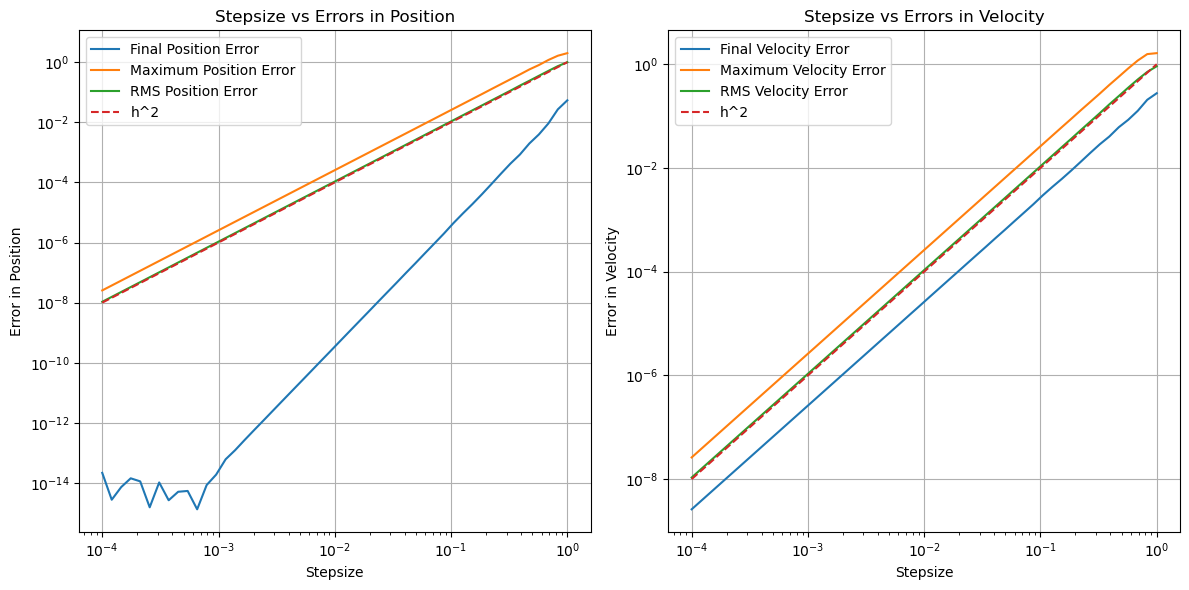

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(stepsizes, final_errors_position, label = 'Final Position Error')
plt.plot(stepsizes, max_errors_position, label = 'Maximum Position Error')
plt.plot(stepsizes, rms_errors_position, label = 'RMS Position Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Position')
plt.title('Stepsize vs Errors in Position')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(stepsizes, final_errors_velocity, label = 'Final Velocity Error')
plt.plot(stepsizes, max_errors_velocity, label = 'Maximum Velocity Error')
plt.plot(stepsizes, rms_errors_velocity, label = 'RMS Velocity Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Velocity')
plt.title('Stepsize vs Errors in Velocity')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()